Settings file (settings.yaml)

In [ ]:
product_A_assumptions = {
    "age": 35,
    "premium": 500,
    "claims_amount": 500000,
    "policyholder_count": 1000,
    "projection_years": 20,
    "interest_rate": 0.05,
    "lapse_vector": [0.1, 0.08] + [0.05]*18,
    "expenses": {
        "commission": 150,
        "maintenance": 50
    },
    "inflation_rate": 0.02
}

product_B_assumptions = {
    "age": 35,
    "premium": 500,
    "claims_amount": 500000,
    "policyholder_count": 1000,
    "projection_years": 20,
    "interest_rate": 0.03,
    "lapse_vector": [0.2, 0.15] + [0.10]*18,
    "expenses": {
        "commission": 100,
        "maintenance": 40
    },
    "inflation_rate": 0.02,
}

Loading data (data_loader.py)

In [ ]:
import pandas as pd

# Loads data from provided VBT Excel file and creates a map of Age/Policy duration -> Mortality
def load_mortality_data(file_name, sheet_name):
  df_raw_vbt = pd.read_excel(file_name, sheet_name=sheet_name, header=None)

  header_row_idx = df_raw_vbt[df_raw_vbt[0] == r"Row\Column"].index[0]
  df_vbt = pd.read_excel(file_name, sheet_name=sheet_name, header = header_row_idx)

  df_vbt = df_vbt.rename(columns={r"Row\Column": "Issue_Age"})
  df_vbt = df_vbt[pd.to_numeric(df_vbt["Issue_Age"], errors='coerce').notnull()]

  df_vbt["Issue_Age"] = df_vbt["Issue_Age"].astype(int)
  df_vbt = df_vbt.dropna()

  df_long = df_vbt.melt(
    id_vars=["Issue_Age"],
    var_name="Duration",
    value_name="Mortality_Rate"
  )

  df_long["Duration"] = pd.to_numeric(df_long["Duration"], errors='coerce')
  # Convert Mortality_Rate to numeric type
  df_long["Mortality_Rate"] = pd.to_numeric(df_long["Mortality_Rate"], errors='coerce')

  mortality_map = df_long.set_index(["Issue_Age", "Duration"])["Mortality_Rate"].to_dict()

  print(f"Loading data from {file_name}...")
  return mortality_map

file_name = input("Enter file name: ")
sheet_name = input("Enter sheet name")

mortality_lookup = load_mortality_data(file_name, sheet_name)

Enter file name: VBT_2015.xlsx
Enter sheet nameSheet1
Loading data from VBT_2015.xlsx...


Actuarial Engine (engine.py)

        POLICY FINANCIAL SUMMARY        
Metric                    |        Value
----------------------------------------
PV Premiums               | $4,207,806.15
PV Claims                 | $2,517,958.39
PV Expenses               | $629,109.74
----------------------------------------
Net Present Value (NPV)   | $1,060,738.02
Profit Margin             |        25.2%
        POLICY FINANCIAL SUMMARY        
Metric                    |        Value
----------------------------------------
PV Premiums               | $3,196,027.04
PV Claims                 | $1,677,387.83
PV Expenses               | $385,329.51
----------------------------------------
Net Present Value (NPV)   | $1,133,309.69
Profit Margin             |        35.5%


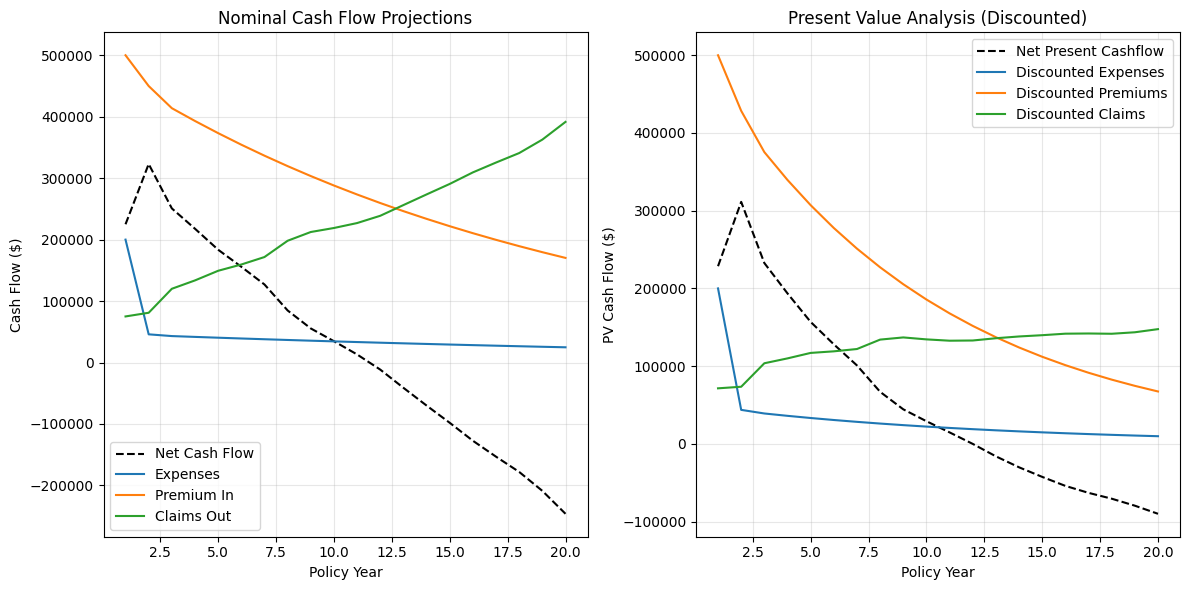

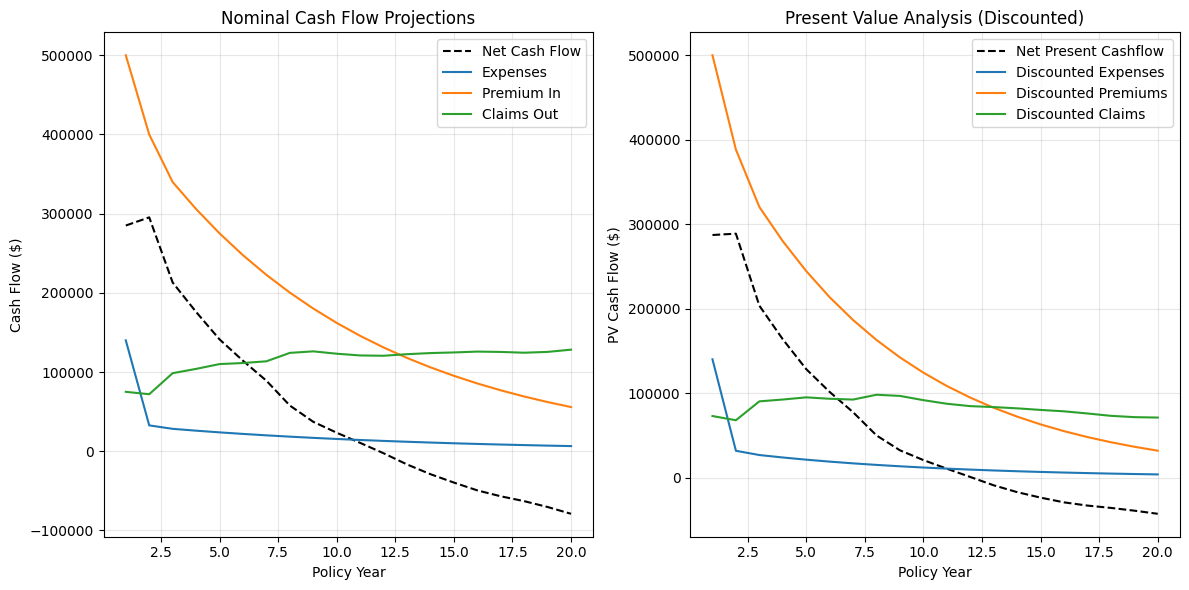

In [ ]:
import pandas as pd
import numpy as np
from dataclasses import dataclass
from typing import Optional



@dataclass
class ProjectionState:
    """
    Holds the state of the projection as NumPy arrays.
    Replaces the DataFrame.
    """
    # Dimensions
    term: int

    # Demographics
    lives_start: np.ndarray
    deaths: np.ndarray
    lapses: np.ndarray
    lives_end: np.ndarray

    # Financials
    premiums: np.ndarray = None
    claims: np.ndarray = None
    expenses: np.ndarray = None
    net_cashflow: np.ndarray = None

    # Valuation
    discount_factors: np.ndarray = None
    pv_cashflow: np.ndarray = None

    @classmethod
    def initialize(cls, term: int):
        """Creates empty arrays of zeros to start."""
        return cls(
            term=term,
            lives_start=np.zeros(term),
            deaths=np.zeros(term),
            lapses=np.zeros(term),
            lives_end=np.zeros(term)
        )


class LifePolicy:
    def __init__(self, mortality_map, assumptions):
        # Base assumptions from config dict
        self.age = assumptions["age"]
        self.premium = assumptions["premium"]
        self.claims = assumptions["claims_amount"]
        self.l0 = assumptions["policyholder_count"]

        self.projection_years = assumptions["projection_years"]
        self.interest_rate = assumptions["interest_rate"]
        self.lapse_rates = assumptions["lapse_vector"]
        self.expenses_comm = assumptions["expenses"]["commission"]
        self.expenses_maint = assumptions["expenses"]["maintenance"]
        self.inflation_rate = assumptions["inflation_rate"]

        self.mortality_map = mortality_map

    def _get_mortality_vector(self):
        return [self.mortality_map.get((self.age, d)) for d in range(1, self.projection_years + 1)]

    def _build_decrement_vectors(self):

        t_len = self.projection_years
        state = ProjectionState.initialize(t_len)

        current_lives = self.l0

        mortality_vec = self._get_mortality_vector()

        for t in range(t_len):
            state.lives_start[t] = current_lives

            q_d = mortality_vec[t]

            d_t = current_lives * q_d
            w_t = (current_lives - d_t) * self.lapse_rates[t]

            state.deaths[t] = d_t
            state.lapses[t] = w_t

            current_lives = current_lives - d_t - w_t
            state.lives_end[t] = current_lives

        return state

    def _calculate_cashflows(self, state: ProjectionState):
        state.premiums = state.lives_start * self.premium
        state.claims = state.deaths * self.claims

        inflation_index = np.power(1 + self.inflation_rate, np.arange(state.term))
        maint_exp = state.lives_start * self.expenses_maint * inflation_index

        acq_exp_total = (self.l0 * self.expenses_comm)
        maint_exp[0] += acq_exp_total

        state.expenses = maint_exp

        state.net_cashflow = state.premiums - state.claims - state.expenses

        return state


    def _apply_discounting(self, state: ProjectionState):
      i = self.interest_rate
      v = 1 / (1 + i)

      time_indices = np.arange(1, state.term + 1)
      discount_start = np.power(v, time_indices - 1)
      discount_end = np.power(v, time_indices)

      state.discount_factors_start = discount_start
      state.discount_factors_end = discount_end

      pv_premiums = state.premiums * discount_start
      pv_claims = state.claims * discount_end
      pv_expenses = state.expenses * discount_start

      state.pv_cashflow = pv_premiums - pv_claims - pv_expenses

      return state


    def run(self) -> ProjectionState:

        state_step1 = self._build_decrement_vectors()
        state_step2 = self._calculate_cashflows(state_step1)
        self.final_state = self._apply_discounting(state_step2)

        return self.final_state


    def summary_metrics(self, verbose: bool = True) -> dict:

      if self.final_state is None:
        raise ValueError("Engine has not run yet. Call (run) first.")

      total_pv_premium = (self.final_state.premiums * self.final_state.discount_factors_start).sum()
      total_pv_claims = (self.final_state.claims * self.final_state.discount_factors_end).sum()
      total_pv_expenses = (self.final_state.expenses * self.final_state.discount_factors_start).sum()
      npv = self.final_state.pv_cashflow.sum()

      metrics = {
        "total_pv_premiums": total_pv_premium,
        "total_pv_claims": total_pv_claims,
        "total_pv_expenses": total_pv_expenses,
        "total_net_cashflow": self.final_state.net_cashflow.sum(),
        "npv": npv,
        "profit_margin": npv / total_pv_premium if total_pv_premium > 0 else 0.0
      }

      if verbose:
        print("=" * 40)
        print(f"{'POLICY FINANCIAL SUMMARY':^40}")
        print("=" * 40)
        print(f"{'Metric':<25} | {'Value':>12}")
        print("-" * 40)

        # Financials w
        print(f"{'PV Premiums':<25} | ${metrics['total_pv_premiums']:,.2f}")
        print(f"{'PV Claims':<25} | ${metrics['total_pv_claims']:,.2f}")
        print(f"{'PV Expenses':<25} | ${metrics['total_pv_expenses']:,.2f}")
        print("-" * 40)

        # Key Performance Indicators
        print(f"{'Net Present Value (NPV)':<25} | ${metrics['npv']:,.2f}")

        margin_label = "Profit Margin"
        print(f"{margin_label:<25} | {metrics['profit_margin']:>12.1%}")
        print("=" * 40)

      return metrics

    def plot_results(self):
      import matplotlib.pyplot as plt
      import seaborn as sns

      if self.final_state is None:
        print("Model not run yet.")
        return

      years = np.arange(1, self.projection_years + 1)
      st = self.final_state


      disc_premiums = st.premiums * st.discount_factors_start
      disc_expenses = st.expenses * st.discount_factors_start

      disc_claims = st.claims * st.discount_factors_end

      fig, ax = plt.subplots(1, 2, figsize=(12, 6))

      sns.lineplot(x=years, y=st.net_cashflow, label="Net Cash Flow", ax=ax[0], color="black", linestyle="--")
      sns.lineplot(x=years, y=st.expenses, label="Expenses", ax=ax[0])
      sns.lineplot(x=years, y=st.premiums, label="Premium In", ax=ax[0])
      sns.lineplot(x=years, y=st.claims, label="Claims Out", ax=ax[0])

      ax[0].set_title("Nominal Cash Flow Projections")
      ax[0].set_xlabel("Policy Year")
      ax[0].set_ylabel("Cash Flow ($)")
      ax[0].legend()
      ax[0].grid(True, alpha=0.3)


      sns.lineplot(x=years, y=st.pv_cashflow, label="Net Present Cashflow", ax=ax[1], color="black", linestyle="--")
      sns.lineplot(x=years, y=disc_expenses, label="Discounted Expenses", ax=ax[1])
      sns.lineplot(x=years, y=disc_premiums, label="Discounted Premiums", ax=ax[1])
      sns.lineplot(x=years, y=disc_claims, label="Discounted Claims", ax=ax[1])
      ax[1].legend()
      ax[1].set_title("Present Value Analysis (Discounted)")
      ax[1].set_xlabel("Policy Year")
      ax[1].set_ylabel("PV Cash Flow ($)")
      ax[1].grid(True, alpha=0.3)

      plt.tight_layout()
      plt.show()


testA = LifePolicy(mortality_map=mortality_lookup, assumptions=product_A_assumptions)

testA.run()
testA.summary_metrics()

testB = LifePolicy(mortality_map=mortality_lookup, assumptions=product_B_assumptions)

testB.run()
testB.summary_metrics()

testA.plot_results()
testB.plot_results()

pass


Margin optimizer (margin_optimizer.py)

In [ ]:
from IPython.core.history import HistorySavingThread
from scipy.optimize import brentq
from typing import Optional

class MarginOptimizer:
    def __init__(self, policy_prototype):
      self.policy = policy_prototype

    def _objective_function(self, premium_guess: float, target_margin: float) -> float:

      self.policy.premium = premium_guess
      self.policy.run()

      metrics = self.policy.summary_metrics(verbose=False)
      current_margin = metrics["profit_margin"]

      return current_margin - target_margin



    def solve_for_premium(self, target_margin: float = 0.07) -> float:

      low_bound = 1
      high_bound = 10000

      try:
        optimal_premium = brentq(
            f=self._objective_function,
            a=low_bound,
            b=high_bound,
            args=(target_margin,),
            xtol=1e-4,
        )
        print(f"Optimization Success! Found Premium: ${optimal_premium:,.2f}")
        return optimal_premium

      except RuntimeError as e:
        print(f"Optimization Failed: Target margin is impossible within bounds ($1 - $10k) {e}")
        return -1


marginA = MarginOptimizer(testA)
marginB = MarginOptimizer(testB)

best_premium_A = marginA.solve_for_premium(target_margin=0.07)
best_premium_B = marginB.solve_for_premium(target_margin=0.07)

Optimization Success! Found Premium: $394.65
Optimization Success! Found Premium: $342.00
